# Assessing levelling results

In [1]:
%load_ext autoreload
%autoreload 2


import logging

import cmocean
import harmonica as hm
import matplotlib.pyplot as plt
import pandas as pd
import plotly.io as pio
import verde as vd
import xrft

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()
pio.renderers.default = "notebook"

## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_magnetic_survey`, and the BAS processing steps are repeated in the notebook `processing_AGAP_magnetic_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_magnetic_survey_processed_blocked.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "mag",
        "mag_microlevelled",
    ]
]

# drop rows with nans
data_df = data_df.dropna(subset=["mag", "mag_microlevelled"], how="any")

# to run faster, limit number of lines
data_df = data_df[data_df.line.between(90, 132)]
# data_df = data_df[~data_df.line.between(133, 142)]
# data_df = data_df[~data_df.line.between(168, 176)]
# data_df = data_df[
#     (data_df.line.isin(data_df.line.unique()[::2])) | (data_df.line >= 143)
# ]

data_df

,easting,northing,height,line,unixtime,distance_along_line,mag,mag_microlevelled
187474,1.336675e+06,529852.459597,2764.10,90,1.230306e+09,319.401104,-0.050,48.940
187475,1.336846e+06,529938.129441,2762.20,90,1.230306e+09,510.510915,-0.020,48.920
187476,1.337019e+06,530020.179327,2759.10,90,1.230306e+09,701.855855,-0.020,48.910
187477,1.337194e+06,530098.449388,2755.80,90,1.230306e+09,893.841920,-0.010,48.890
187478,1.337371e+06,530172.525178,2753.90,90,1.230306e+09,1086.016098,0.070,48.880
...,...,...,...,...,...,...,...,...
244079,1.605652e+06,538829.512365,2510.80,132,1.231012e+09,342501.172542,-33.130,-24.730
244080,1.605848e+06,538860.754464,2511.35,132,1.231012e+09,342699.565881,-31.315,-23.340
244081,1.606043e+06,538893.039905,2513.70,132,1.231012e+09,342897.090968,-29.410,-21.830
244082,1.606236e+06,538926.185878,2516.05,132,1.231012e+09,343093.093780,-27.630,-20.145


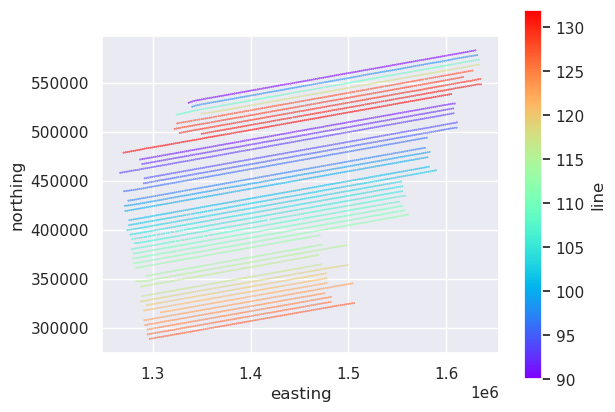

In [3]:
ax = data_df[::10].plot.scatter(
    "easting",
    "northing",
    c="line",
    s=0.1,
    cmap="rainbow",
)
ax.set_aspect("equal")

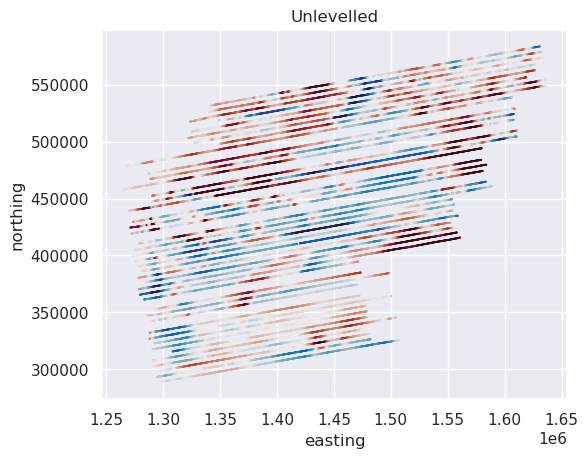

In [4]:
max_abs = vd.maxabs(data_df.mag, percentile=95)
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="mag",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")

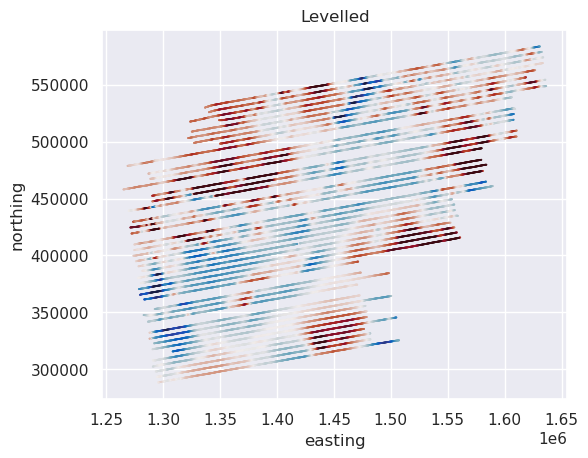

In [5]:
ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="mag_microlevelled",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Levelled",
)
ax.set_aspect("equal")

## Grid the pre and post-levelled data

In [6]:
# # block reduce the line data
# data_df = airbornegeo.block_reduce(
#     data_df,
#     np.median,
#     spacing=1000,
#     reduce_by="distance_along_line",
#     groupby_column="line",
# )
data_df = data_df.dropna(subset=["easting", "northing", "height", "mag"])
data_df.describe()

,easting,northing,height,line,unixtime,distance_along_line,mag,mag_microlevelled
count,5.628900e+04,56289.000000,56289.000000,56289.000000,5.628900e+04,56289.000000,56289.000000,56289.000000
mean,1.430888e+06,440774.734023,2833.793995,109.735614,1.230766e+09,138675.221903,11.137684,13.071603
std,8.764038e+04,75623.242557,299.401503,12.951445,5.970691e+05,86087.504029,71.123537,68.555962
min,1.265051e+06,288405.943057,2205.600000,90.000000,1.229705e+09,69.881146,-220.750000,-212.845000
25%,1.359261e+06,381286.784441,2516.350000,98.000000,1.230119e+09,65934.803785,-31.700000,-29.160000
50%,1.425523e+06,441810.741084,3047.600000,109.000000,1.230984e+09,131699.605960,5.300000,2.550000
75%,1.496425e+06,506067.486182,3060.650000,121.000000,1.231322e+09,204233.685193,42.420000,43.600000
max,1.636624e+06,583631.182407,3264.050000,132.000000,1.231588e+09,348640.492375,921.050000,991.080000


In [7]:
coords = (
    data_df.easting,
    data_df.northing,
    data_df.height,
)

In [ ]:
eqs_kwargs = {
    "damping": 0.1,
    "depth": "default",
    "block_size": 2e3,
}

# eqs = hm.EquivalentSourcesGB(
#     window_size=200e3,
#     random_state=42,
#     **eqs_kwargs,
# )

eqs = hm.EquivalentSources(**eqs_kwargs)

bytes = eqs.estimate_required_memory(coords)
print(f"{bytes / 1e9} GB ram required")

2.931080808 GB ram required


In [9]:
eqs.fit(coords, data_df.mag)

,damping,0.1
,points,None
,depth,'default'
,block_size,2000.0
,parallel,True
,dtype,'float64'


In [10]:
# Define grid coordinates
grid_coords = vd.grid_coordinates(
    region=vd.pad_region(vd.get_region(coords), 10e3),
    spacing=2000,
    extra_coords=4200,  # upward continue
    adjust="region",
)
grid_unlevelled = eqs.grid(grid_coords)

# grid_unlevelled = vd.distance_mask(
#     (coords[0], coords[1]), maxdist=10e3, grid=grid_unlevelled
# )
grid_unlevelled = grid_unlevelled.reset_coords(names="upward").scalars

In [11]:
eqs.fit(coords, data_df.mag_microlevelled)

,damping,0.1
,points,None
,depth,'default'
,block_size,2000.0
,parallel,True
,dtype,'float64'


In [12]:
grid_levelled = eqs.grid(grid_coords)

# grid_levelled = vd.distance_mask(
#     (coords[0], coords[1]), maxdist=10e3, grid=grid_levelled
# )
grid_levelled = grid_levelled.reset_coords(names="upward").scalars

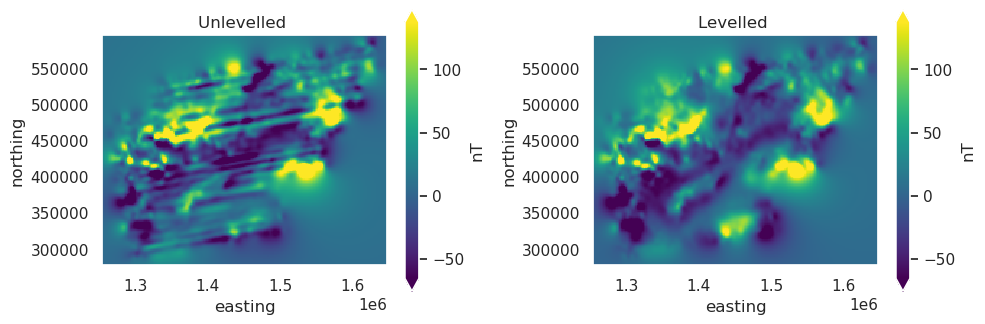

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

vmin, vmax = vd.minmax(
    grid_unlevelled, grid_levelled, min_percentile=2, max_percentile=98
)

grid_unlevelled.plot(
    ax=axs[0],
    cbar_kwargs={
        "shrink": 0.5,
        "label": "nT",
    },
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_title("Unlevelled ")
axs[0].set_aspect("equal")

grid_levelled.plot(
    ax=axs[1],
    cbar_kwargs={
        "shrink": 0.5,
        "label": "nT",
    },
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_title("Levelled ")
axs[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## Compute power spectra
Power spectra of the unlevelled and levelled grids should show if there is a dominant angle of high power, which likely corresponds to levelling errors between lines.

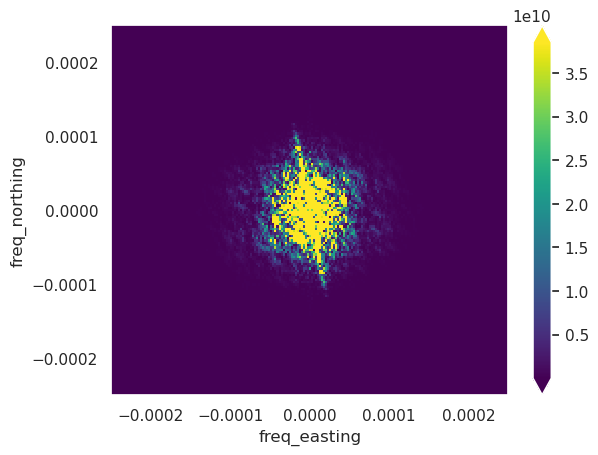

In [14]:
powerspec_unlevelled = xrft.power_spectrum(grid_unlevelled)
powerspec_unlevelled.plot(
    robust=True,
)

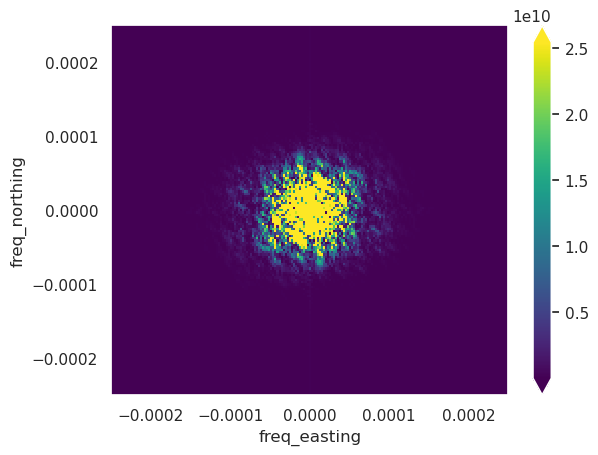

In [15]:
powerspec_levelled = xrft.power_spectrum(grid_levelled)
powerspec_levelled.plot(
    robust=True,
)

Below we show the power spectra differences of the above two plots.

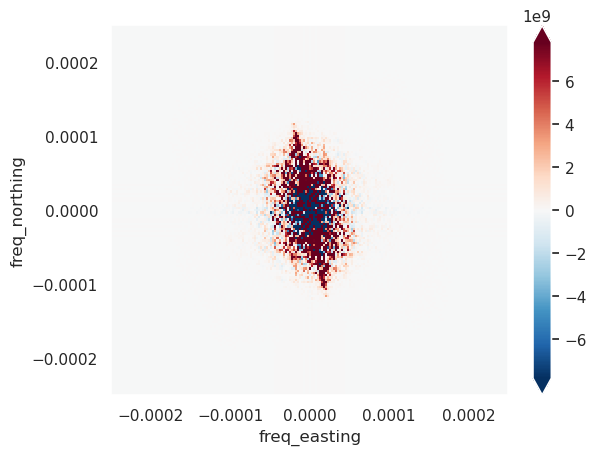

In [16]:
(powerspec_unlevelled - powerspec_levelled).plot(
    robust=True,
)

## Use spatial derivatives to assess levelling performance

In [17]:
hg_unlevelled = airbornegeo.filter_grid(
    grid_unlevelled, filter_type="horizontal_gradient"
)
hg_levelled = airbornegeo.filter_grid(grid_levelled, filter_type="horizontal_gradient")

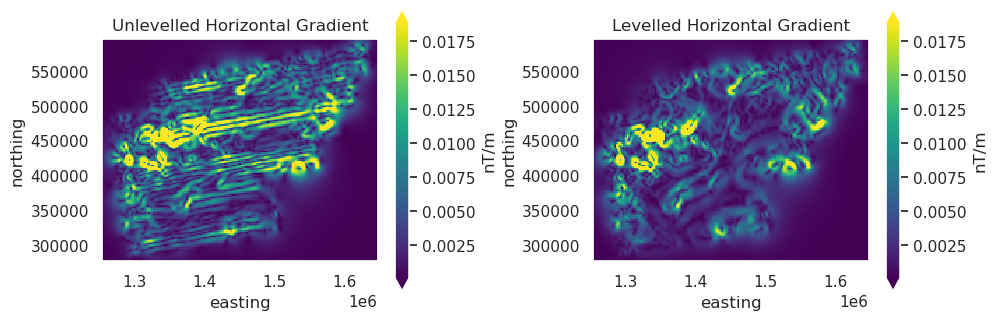

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

vmin, vmax = vd.minmax(hg_unlevelled, hg_levelled, min_percentile=2, max_percentile=98)

hg_unlevelled.plot(
    ax=axs[0],
    cbar_kwargs={
        "shrink": 0.5,
        "label": "nT/m",
    },
    vmin=vmin,
    vmax=vmax,
)
axs[0].set_title("Unlevelled Horizontal Gradient")
axs[0].set_aspect("equal")

hg_levelled.plot(
    ax=axs[1],
    cbar_kwargs={
        "shrink": 0.5,
        "label": "nT/m",
    },
    vmin=vmin,
    vmax=vmax,
)
axs[1].set_title("Levelled Horizontal Gradient")
axs[1].set_aspect("equal")

plt.tight_layout()
plt.show()

The above plots show the horizontal gradients for the unlevelled and levelled grids. These highlight the levelling errors in the data. These errors appear to be significantly reduced with the levelling. One way to quantify these errors is to compute the RMS of the grid values and the grid with levelling errors will results in more regions of high horizontal gradients, and therefore a higher RMS.

In [19]:
airbornegeo.rmse(hg_unlevelled), airbornegeo.rmse(hg_unlevelled, as_median=True)

(np.float64(0.007249995388107783), np.float64(0.0024966570718239225))

In [20]:
airbornegeo.rmse(hg_levelled), airbornegeo.rmse(hg_levelled, as_median=True)

(np.float64(0.005969627985511294), np.float64(0.001909999474629751))

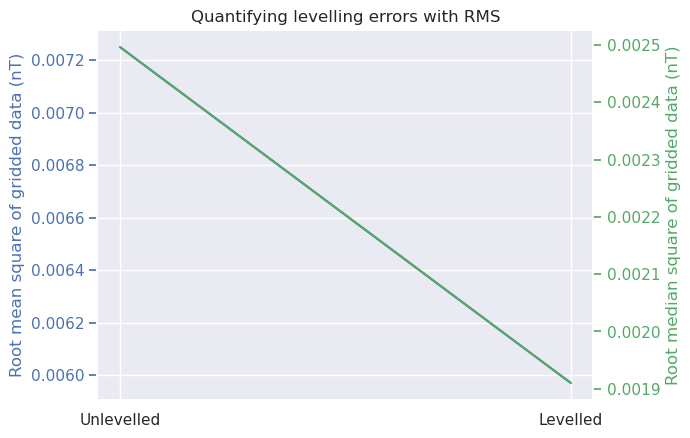

In [40]:
fig, ax = plt.subplots(1, 1, sharex=True)
ax.plot(
    ["Unlevelled", "Levelled"],
    [airbornegeo.rmse(hg_unlevelled), airbornegeo.rmse(hg_levelled)],
    c="b",
)
ax.set_ylabel("Root mean square of gridded data (nT)", color="b")
ax.tick_params(axis="y", colors="b", which="both")

ax2 = ax.twinx()
ax2.plot(
    ["Unlevelled", "Levelled"],
    [
        airbornegeo.rmse(hg_unlevelled, as_median=True),
        airbornegeo.rmse(hg_levelled, as_median=True),
    ],
    c="g",
)
ax2.grid(visible=False)
ax2.set_ylabel("Root median square of gridded data (nT)", color="g")
ax2.tick_params(axis="y", colors="g", which="both")

plt.title("Quantifying levelling errors with RMS");

Additionally, we can plot the power spectra of the horizontal gradients of the levelled and unlevelled data. These show a single angle of high power in the data, which is from the levelling errors.

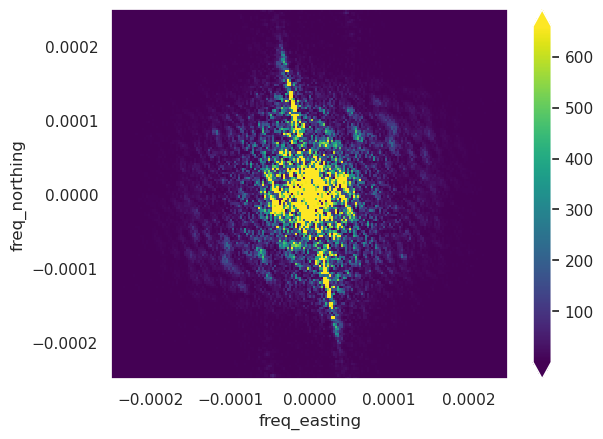

In [21]:
powerspec_unlevelled = xrft.power_spectrum(hg_unlevelled)
powerspec_unlevelled.plot(
    robust=True,
)

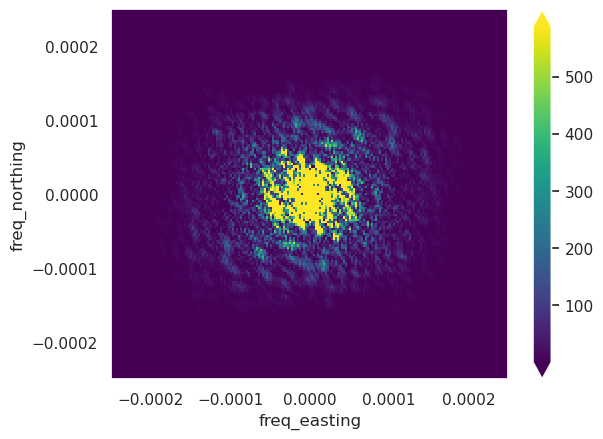

In [22]:
powerspec_levelled = xrft.power_spectrum(hg_levelled)
powerspec_levelled.plot(
    robust=True,
)

Below we show the power spectra differences of the above two plots.

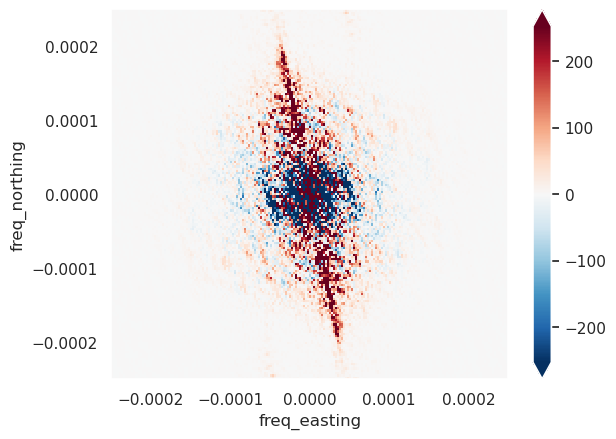

In [23]:
(powerspec_unlevelled - powerspec_levelled).plot(
    robust=True,
)